In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,4)

import librosa
import librosa.display
from scipy.signal import find_peaks
from IPython.display import Audio
from scipy.signal import sawtooth, square, butter, filtfilt

# Pitch Tracking

In fundamental frequency detection (or pitch detection if we convert), we estimate f0 in signals we assume are periodic (or quasi-periodic). 

Pitch estimation is used for melody transcription, real-time pitch recognition, and pitch editing or correction.

Today, we are going to discuss methods for F0 detection of monophonic signals.



### Fundamental Frequency 
The fundamental frequency is the lowest frequency of a periodic signal.

Recall, f0 is inversely related to the period of the waveform.

$$f0 = \frac{1}{T}$$

We can convert from frequency to MIDI pitch with this equation. 

$$ 69 + 12 log_2(\frac{f}{440})$$

Sinusoid detection is easy because it only includes one frequency (the fundamental), but with real-life signals, f0 detection is a little more complicated due to the additional harmonics and partials present. Additionally, music signals like human singing often have slight variation in frequency (vibrato) even though the perceived pitch is the same.

However, even when we have many partials present, they are often integer-related (harmonics) or follow a predictable pattern. We can use this to our advantage in pitch detection.

In [44]:
# load default is sr=22050, and convert to mono = True
x, fs = librosa.load('../audio/femaleSingingScale.wav')
x = x/np.abs(x.max())

Audio(x, rate=fs)

Note: I am using librosa load to downsample our signal to 22050 Hz. It's common practice when examining spectral content for large quantities of analysis to **downsample by half (so go from 44.1 to 22.05 kHz).** This reduces the overall amount of processing by 1/2. In this case, the Nyquist will be ~11kHz which still has most music data we need and doesn't impact overall results much.

In [45]:
# low pass filter
cutoff = 2500
order = 5

(b, a) = butter(order, cutoff, btype='lowpass', fs=fs)

x = filtfilt(b, a, x)

Here is what we should expect from our pitch detection of this signal.

A3, C4, C#4, D4, E4, D4, C#4, B3, A3

Which corresponds to midi numbers: 57, 60, 61, 62, 64, 62, 61, 59, 57

And frequencies: 220.00, 261.63, 277.18, 293.66, 329.63, 293.66, 277.18, 246.94, 220.00 (assuming perfect intonation)

### STFT

Let's start off with the STFT. This may seem like an obvious pathway to f0 detection. We can take our time signal, flip it to the frequency domain, then find the frequency peaks each frame to infer the fundamental.

Let's try it.

In [46]:
frame_length = 4096
hop_length = 512

stft = np.abs(librosa.stft(x, n_fft=frame_length, hop_length=hop_length))


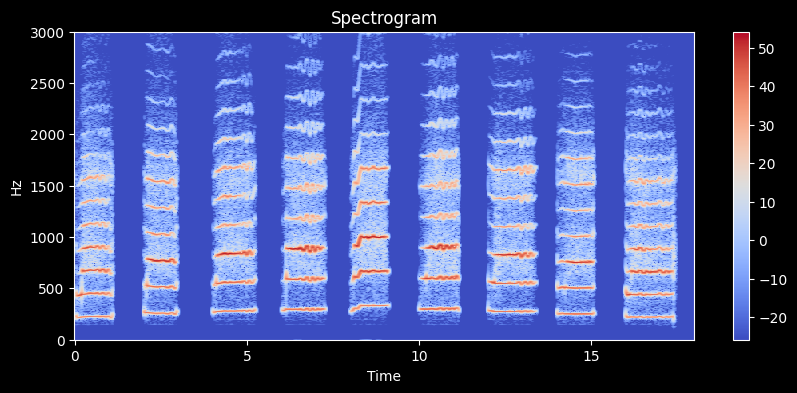

In [47]:
librosa.display.specshow(librosa.amplitude_to_db(stft), sr=fs, hop_length=hop_length, x_axis='time', y_axis='hz')

plt.ylim((0, 3000))
plt.title("Spectrogram")
plt.colorbar()

Remember, the STFT produces a matrix X[m, k] where m is the frame index and k is the frequency bin.

We'll look at the frequencies in the first frame.

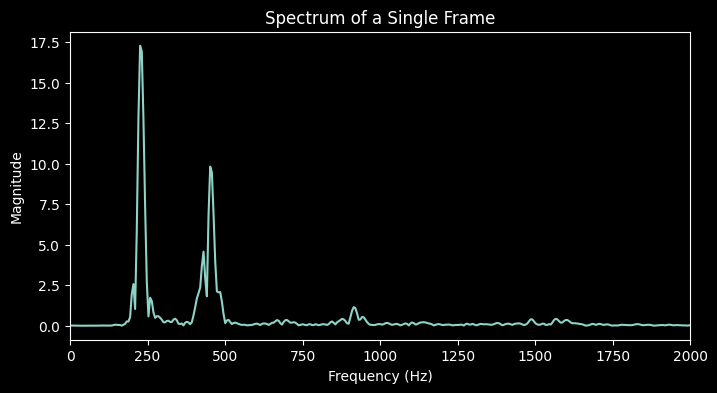

In [48]:
spectrum = stft[:, 0]

# convert x-axis to frequency in Hz
freqs = np.linspace(0, fs/2, len(spectrum))

plt.figure(figsize=(8,4))
plt.plot(freqs, spectrum)
plt.xlim(0,2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Spectrum of a Single Frame")
plt.show()

We can apply the same peak picking algorithms we used for onset detection. For now, I'm going to choose the max of the frame as the fundamental. 

In practice, this may be inaccurate because although the fundamental often has strong energy, many instruments have stronger upper harmonics. In these cases, you may want to use a peak picking algorithm and the minimum peak position.

In [49]:
# get location (bin) with the greatest magnitude
max_bin = np.argmax(spectrum)
print(max_bin)

42


In [50]:
# convert to bin number to frequency in Hz
f0 = max_bin * fs / frame_length
f0

226.0986328125

In [51]:
pitch = 69 + 12 * np.log2(f0/440)
pitch

57.47338493503615

So, for our first frame (samples 0 to 4096) the majority of the energy is in bin 42 or at frequency 226.1 Hz. 

We would then go across each frame and find the max (our peak pick) each frame to estimate pitch across the signal.

The problem with just using the STFT is the time vs frequency resolution tradeoff. 

It works well for this file because there is not much frequency change over long periods of time. However, if our signal had more frequency change, we'd have to balance frequency bin resolution and discrete time resolution.

Even in this example, our next frequency we are trying to find is 261.2 Hz, but our STFT does not current map to that frequency, so we'll have energy in bin 48 and bin 49.

In [52]:
bin_48 = 48 * fs / frame_length
bin_49 = 49 * fs / frame_length

print(bin_48, bin_49)

258.3984375 263.78173828125


If we use larger time windows, we will get better frequency resolution, but we will not be able to pin point the frequencies to specific time positions.

We can get better frequency resolution via upsampling and interpolation (zero padding). However, this increases computational load.

## Time Domain Approach

We can actually use time domain based approaches to calculate f0 for monophonic signals.

### ZCR

As we've discussed, ZCR counts the number of times a signal crosses zero. We can take advantage of this to calculate periodicity if we know our signal is monophonic and periodic. This is very computationally efficient.

Because the a single cycle produces 2 zero crossings, we can say

$$f = \frac{ZCR*fs}{2} $$

In [53]:
t = np.linspace(0, 1, 44100)
sine = np.sin(2*np.pi*5*t)

In [54]:
zero_crossings = np.where(np.diff(np.sign(sine)))[0]
zcr = len(zero_crossings)
zcr / 2


5.0

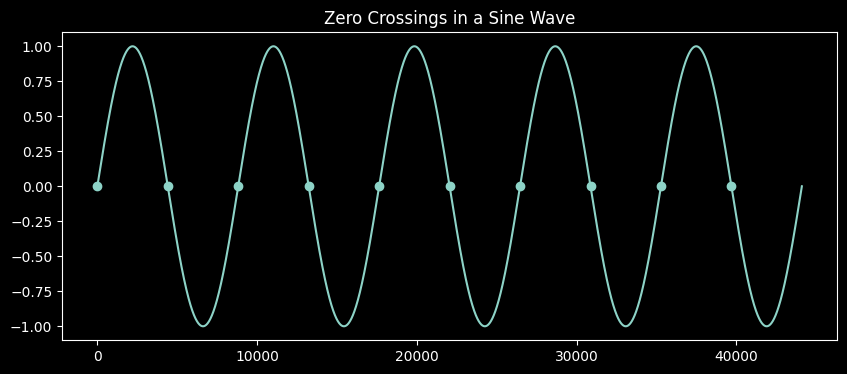

In [55]:
plt.plot(sine)
plt.scatter(zero_crossings, sine[zero_crossings])

plt.title("Zero Crossings in a Sine Wave")
plt.show()

Let's try applying to our audio file. We will take a frame based ZCR. The librosa zcr function returns a fraction of ZCRs per frame, so we multiply by sampling rate to get back to frequency.

In [56]:
frame_length = 2048
hop_length = 1024

zcr = librosa.feature.zero_crossing_rate(x, frame_length=frame_length, hop_length=hop_length)[0]

In [57]:
f0_estimates = (zcr * fs) / 2

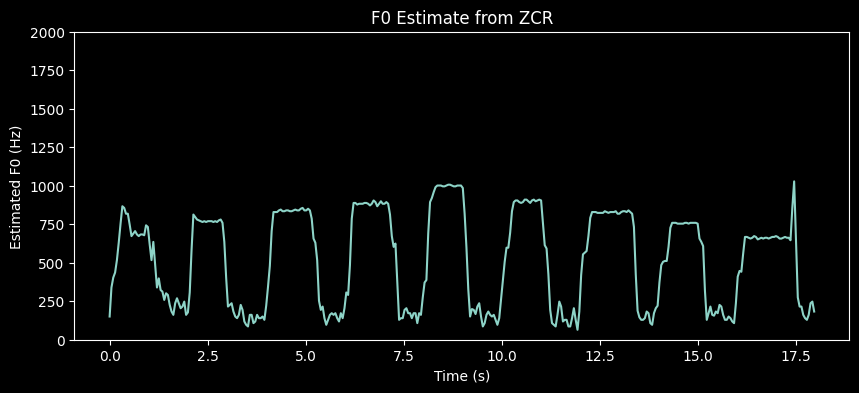

In [58]:
times = librosa.frames_to_time(np.arange(len(f0_estimates)), sr=fs, hop_length=hop_length)

plt.plot(times, f0_estimates)

plt.xlabel("Time (s)")
plt.ylabel("Estimated F0 (Hz)")
plt.ylim(0, 2000)
plt.title("F0 Estimate from ZCR")
plt.show()

As you see, this did not estimate our F0 well. Though it is computationally efficient, applying ZCR like this really only works well on simple signals like sinusoids. 

We can make improvements to this ZCR based algorithm by finding the time distance between zero-crossings (each would be a half period) and by filtering out high/extraneous frequencies.

### Autocorrelation

We can still use the time domain and get roughly accurate results using autocorrelation.

Recall, autocorrelation measures how similar a signal is to shifted versions of itself.

If a waveform repeats every period T, the autocorrelation will produce peaks at T, 2T, 3T, etc.

The first peak after lag 0 corresponds to the fundamental period.

Text(0.5, 1.0, 'Autocorrelation')

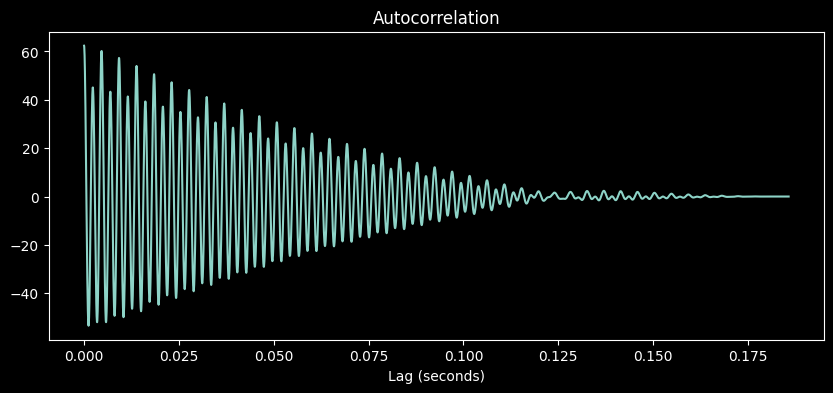

In [59]:
# compute autocorrelation for a small section
ac = librosa.autocorrelate(x[:4096])

lags = np.arange(len(ac))
times = lags / fs

plt.plot(times, ac)
# plt.xlim(0, 2)
plt.xlabel("Lag (seconds)")
plt.title("Autocorrelation")

In [60]:
peaks, _ = find_peaks(ac[1:])

f0_candidates = 1 / (peaks / fs)

first_peak = f0_candidates[0]
print(first_peak)

441.0


Notice that similar to tempo detection, we get doubling with our F0 autocorrelation estimate. We were expecting A3, but got A4.

## Frequency Domain Approach (modified)

### Cepstrum Analysis

We can go back to the frequency domain, but this time rather than just finding peaks in the magnitude spectrum, we'll find periodicity of the spectrum itself. 

The cepstrum separates out a strong pitched compoenent from the rest of the spectrum. This works well for signals where we can assume a ((usually pitched)) excitation and resonance paradigm (most musical instruments). 

The cepstrum is the inverse fourier transform of the log-magnitude fourier transform.

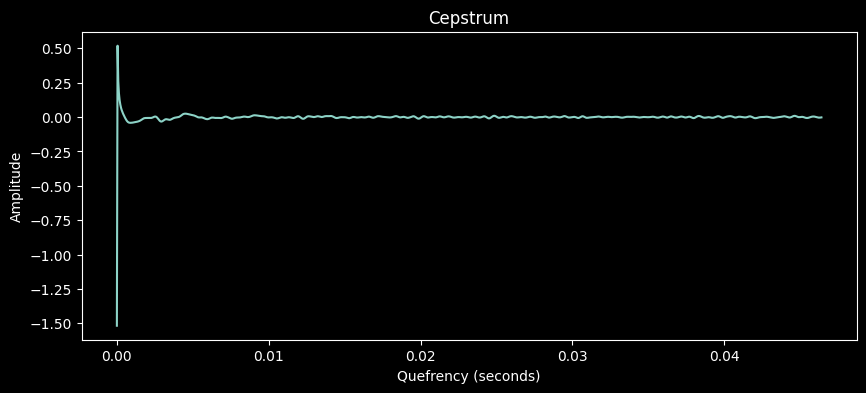

In [67]:
spectrum = np.fft.fft(x[:2048])

log_spectrum = np.log(np.abs(spectrum))

cepstrum = np.real(np.fft.ifft(log_spectrum))

quefrency = np.arange(len(cepstrum)) / fs

plt.plot(quefrency[:1024], cepstrum[:1024])

plt.xlabel("Quefrency (seconds)")
plt.ylabel("Amplitude")

plt.title("Cepstrum")

plt.show()

The cepstrum gives usa time sequence where strong pitched signals will show up as peaks. We can calculate the frequency of these fundamental peaks using the time from 0 to peak.

In [62]:
min_f = 80
max_f = 1000

min_q = int(fs/max_f)
max_q = int(fs/min_f)

peak = np.argmax(cepstrum[min_q:max_q]) + min_q

T0 = peak / fs
f0 = 1 / T0

print("Estimated F0:", f0)

Estimated F0: 222.72727272727272


Cepstrum "deconvolves" two convolved spectra: the excitation (initial signal) and resonance (impulse response). 

This is really helpful for speech sounds. If the excitation is pitched, it is likely a vowel sound, whereas, if there is no peak in the cepstrum, it is likely a consonant sound.

### Built In Function

We can compare our pitch detection with the librosa function pyin.

It uses the YIN algorithm which is similar to autocorrelation, but instead of just comparing the signal to itself, you compute the cumulative mean of different lag times which better isolates the fundamental frequencies.

In [63]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    x,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C7')
)

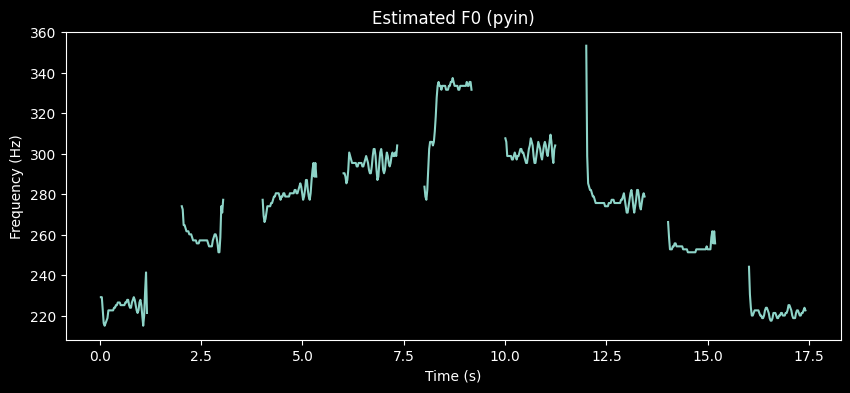

In [64]:
times = librosa.times_like(f0)

plt.figure(figsize=(10,4))

plt.plot(times, f0)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.title("Estimated F0 (pyin)")

plt.show()

### Polyphonic Pitch Detection

All methods we've discussed are for monophonic signals. Polyphonic pitch detection is much more complicated. We may have overlapping harmonics, masking effects, simultaneous note changes, and many different timbres in polyphonic signals.


## Chromagrams

To set up our discussion of key finding next week, I'm going to introduce chromagrams. This is another way to look at pitch information of our signal. Chromagrams are kind of like spectrograms, but instead of equally spaced frequency bins, we scale the bin sizes to better match our perception.

Chromagrams are a representation of the energy of a signal in terms of its *pitch class* (chroma) content. Therefore, the entire spectrum for a segment of audio is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the octave. **The chroma representation tells us the intensity of each of the 12 distinct musical chroma of the octave at each time frame.**

Chromagrams are very useful in a number of frequency-related tasks, such as key detection, chord dectection, and cover song ID, because they capture harmonic and melodic characteristics of music, while being robust to changes in timbre and instrumentation.

Within signal processing, chroma-based audio features are sometimes referred to as "pitch class profiles".
To calculate a chromagram, we take a spectrogram and convert the linear frequency axis to a logarithmic one. The signal is decomposed into a large number of equally-spaced frequency bands with center frequencies typically corresponding to the pitches A0 (midi 21) to C8 (midi 108) (or the 88 piano keys), such that each band is a semitone. 

The chroma content is then calculated by summing the *log-frequency* magnitude spectrum across pitches that have an octave relation (e.g., sum A0 + A1 + A2 ... to get the energy for how much "A" there is in a signal.)

Note that different music scholars use the term **pitch class profile** in different ways. When MIR people say "pitch class profiles" they are referring to how much energy in the signal there is at each pitch class. In music perception and cognition, "pitch class profiles" are perceptually derived scales of how well each scale degree "fits" in a tonal key.
### Librosa functions

Librosa has three *varieties* for computing chromagrams, but we will just be using this one:

* librosa.feature.chroma_stft  

This is the 'basic' chromagram computation.
You must pass either a $y$ value to `feature.chroma_stft` which would be an audio signal, or else an $S$ value, which would be a pre-computed energy (magnitude) spectrum (i.e., STFT via `numpy`)

Package details [here](https://librosa.github.io/librosa/generated/librosa.feature.chroma_stft.html)

In [65]:
chromagram = librosa.feature.chroma_stft(y=x, n_fft=4096,sr=fs, hop_length=2048)

The result is a chroma representation which is a 12-element multidimensional array or matrix, where each row represents the
spectral energy corresponding to one pitch class (i.e. C, C#, D, D#, etc.). Each column represents the subsequent sliding window of each STFT window. (Exactly like regular STFT representation.

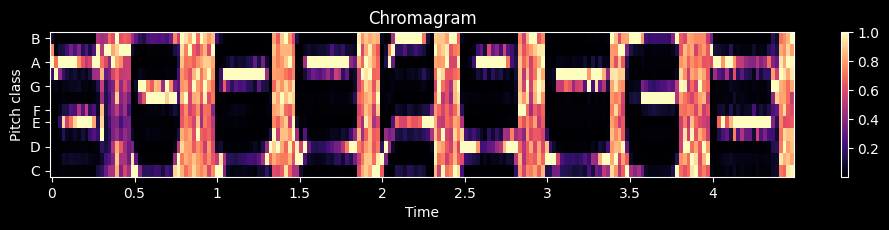

In [66]:
#plt.figure(figsize=(16, 6))
ax = plt.subplot(2,1,1)
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time') # this creates the graph
plt.colorbar() #this adds the legend
plt.title('Chromagram')
plt.tight_layout()